# Linear regression in diabetes dataset

Let's explore the datasets that are included in this Python library. These datasets have been cleaned and formatted for use in ML algorithms.

First, we will load the diabetes dataset. Do this in the cell below by importing the datasets and then loading the dataset  to the `diabetes` variable using the `load_diabetes()` function ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)).

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')

In [2]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

In [3]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

Let's explore this variable by looking at the different attributes (keys) of `diabetes`. Note that the `load_diabetes` function does not return dataframes. It returns you a Python dictionary.

In [4]:
diabetes.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

#### The next step is to read the description of the dataset. 

Print the description in the cell below using the `DESCR` attribute of the `diabetes` variable. Read the data description carefully to fully understand what each column represents.

*Hint: If your output is ill-formatted by displaying linebreaks as `\n`, it means you are not using the `print` function.*

In [5]:
print(diabetes['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

#### Based on the data description, answer the following questions:

1. How many attributes are there in the data? What do they mean?

1. What is the relation between `diabetes['data']` and `diabetes['target']`?

1. How many records are there in the data?

In [6]:
# Respuestas:

# 1. Hay 10 atributos (features):
#    - age: edad en años
#    - sex: sexo
#    - bmi: índice de masa corporal
#    - bp:  presión arterial media
#    - s1:  colesterol sérico total (tc)
#    - s2:  lipoproteínas de baja densidad (ldl)
#    - s3:  lipoproteínas de alta densidad (hdl)
#    - s4:  colesterol total / HDL (tch)
#    - s5:  log de nivel de triglicéridos séricos (ltg)
#    - s6:  nivel de glucosa en sangre (glu)
#    Todos están estandarizados (media 0, suma de cuadrados = 1).

# 2. diabetes['data'] contiene las variables predictoras (X): la matriz de 442x10.
#    diabetes['target'] contiene la variable objetivo (y): una medida cuantitativa
#    de la progresión de la diabetes un año después del baseline.
#    Cada fila de 'data' corresponde al mismo índice en 'target'.

# 3. Hay 442 registros (pacientes).

print("Número de atributos:", len(diabetes['feature_names']))
print("Nombres de atributos:", diabetes['feature_names'])
print("Número de registros:", diabetes['data'].shape[0])

Número de atributos: 10
Nombres de atributos: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Número de registros: 442


#### Now explore what are contained in the *data* portion as well as the *target* portion of `diabetes`. 

Scikit-learn typically takes in 2D numpy arrays as input (though pandas dataframes are also accepted). Inspect the shape of `data` and `target`. Confirm they are consistent with the data description.

In [7]:
print("Shape de diabetes['data']:  ", diabetes['data'].shape)
print("Shape de diabetes['target']:", diabetes['target'].shape)
print()
print("Primeras 5 filas de 'data':")
print(diabetes['data'][:5])
print()
print("Primeros 5 valores de 'target':")
print(diabetes['target'][:5])

Shape de diabetes['data']:   (442, 10)
Shape de diabetes['target']: (442,)

Primeras 5 filas de 'data':
[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]

Primeros 5 valores de 'target':
[151.  75. 141. 206. 135.]


## Building a regression model

The data have already been split to predictor (*data*) and response (*target*) variables. Given this information, we'll apply what we have previously learned about linear regression and apply the algorithm to the diabetes dataset.

#### In the cell below, import the `linear_model` class from `sklearn`. 

In [8]:
from sklearn.linear_model import LinearRegression

#### Create a new instance of the linear regression model and assign the new instance to the variable `diabetes_model`.

In [9]:
diabetes_model = LinearRegression()

#### Next, let's split the training and test data.

Define `diabetes_data_train`, `diabetes_target_train`, `diabetes_data_test`, and `diabetes_target_test`. Use the last 20 records for the test data and the rest for the training data.

In [10]:
# Los últimos 20 registros son el test set; el resto es el train set
diabetes_data_train   = diabetes['data'][:-20]
diabetes_target_train = diabetes['target'][:-20]

diabetes_data_test    = diabetes['data'][-20:]
diabetes_target_test  = diabetes['target'][-20:]

print("Train data shape: ", diabetes_data_train.shape)
print("Train target shape:", diabetes_target_train.shape)
print("Test data shape:  ", diabetes_data_test.shape)
print("Test target shape: ", diabetes_target_test.shape)

Train data shape:  (422, 10)
Train target shape: (422,)
Test data shape:   (20, 10)
Test target shape:  (20,)


Perform a brief exploratory analysis to investigate the conditions necessary for linear regression. This analysis will help you understand the distribution of the target variable and its correlations with other features.

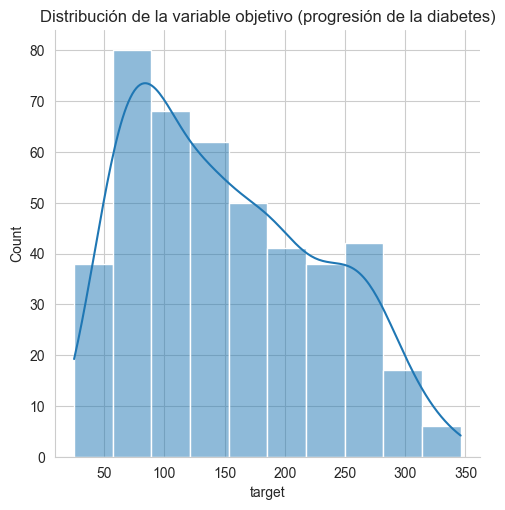

In [11]:
# Convertimos a DataFrame para facilitar el análisis exploratorio
df = pd.DataFrame(diabetes['data'], columns=diabetes['feature_names'])
df['target'] = diabetes['target']

# Distribución de la variable objetivo
sns.displot(df['target'], kde=True)
plt.title('Distribución de la variable objetivo (progresión de la diabetes)')
plt.show()

# La distribución del target es aproximadamente normal → condición favorable para regresión lineal

Correlación de cada variable con el target:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64


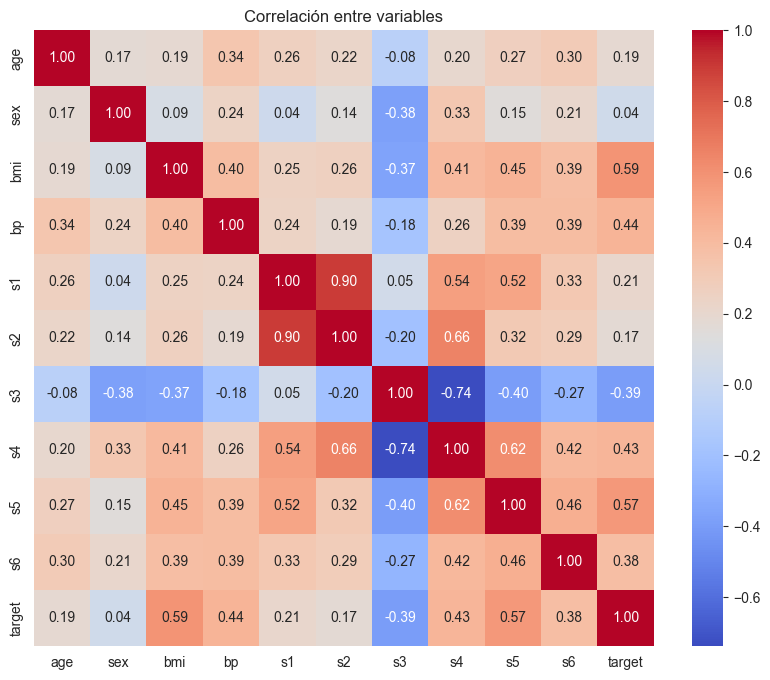

In [12]:
# Correlación de cada feature con el target
correlaciones = df.corr(numeric_only=True)['target'].drop('target').sort_values(ascending=False)
print("Correlación de cada variable con el target:")
print(correlaciones)

# Mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación entre variables')
plt.show()

Fit the training data and target to `diabetes_model`. Print the *intercept* and *coefficients* of the model.

In [13]:
# Entrenamos el modelo
diabetes_model.fit(diabetes_data_train, diabetes_target_train)

# Intercepto y coeficientes
print("Intercepto:", diabetes_model.intercept_)
print()
coeff_df = pd.DataFrame(diabetes_model.coef_, diabetes['feature_names'], columns=['Coefficient'])
print(coeff_df)

Intercepto: 152.76429169049118

     Coefficient
age     0.306094
sex  -237.635570
bmi   510.538048
bp    327.729878
s1   -814.111926
s2    492.799595
s3    102.841240
s4    184.603496
s5    743.509388
s6     76.096646


#### Inspecting the results

From the outputs you should have seen:

- The intercept is a float number.
- The coefficients are an array containing 10 float numbers.

This is the linear regression model fitted to your training dataset.

#### Using your fitted linear regression model, predict the *y* of `diabetes_data_test`.

In [14]:
# Predicciones sobre el test set
predictions = diabetes_model.predict(diabetes_data_test)
print("Predicciones del modelo:")
print(predictions)

Predicciones del modelo:
[197.61898486 155.44031962 172.88875144 111.53270645 164.79397301
 131.06765869 259.12441219 100.47873746 117.06005372 124.30261597
 218.36868146  61.19581944 132.24837933 120.33293546  52.54513009
 194.03746764 102.5756431  123.56778709 211.03465323  52.60221696]


#### Print your `diabetes_target_test` and compare with the prediction. 

     Real    Predicho  Diferencia
0   233.0  197.618985   35.381015
1    91.0  155.440320  -64.440320
2   111.0  172.888751  -61.888751
3   152.0  111.532706   40.467294
4   120.0  164.793973  -44.793973
5    67.0  131.067659  -64.067659
6   310.0  259.124412   50.875588
7    94.0  100.478737   -6.478737
8   183.0  117.060054   65.939946
9    66.0  124.302616  -58.302616
10  173.0  218.368681  -45.368681
11   72.0   61.195819   10.804181
12   49.0  132.248379  -83.248379
13   64.0  120.332935  -56.332935
14   48.0   52.545130   -4.545130
15  178.0  194.037468  -16.037468
16  104.0  102.575643    1.424357
17  132.0  123.567787    8.432213
18  220.0  211.034653    8.965347
19   57.0   52.602217    4.397783


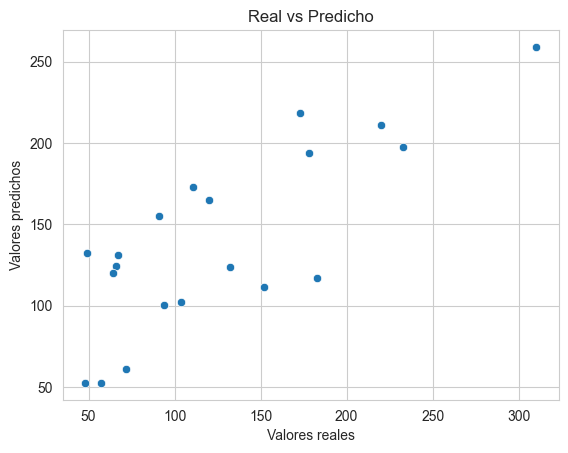

In [15]:
# Comparación valores reales vs predichos
comparison = pd.DataFrame({'Real': diabetes_target_test, 'Predicho': predictions})
comparison['Diferencia'] = comparison['Real'] - comparison['Predicho']
print(comparison.to_string())

# Scatter plot real vs predicho
sns.scatterplot(x=diabetes_target_test, y=predictions)
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.title('Real vs Predicho')
plt.show()

#### Is `diabetes_target_test` exactly the same as the model prediction? Use different error metrics

=== Métricas del modelo (Modelo 1 — todas las variables) ===
MAE  (Error Absoluto Medio):            36.61
MAPE (Error Absoluto Porcentual Medio):  39.31 %
MSE  (Error Cuadrático Medio):           2004.52
RMSE (Raíz del Error Cuadrático Medio):  44.77
R²   (Coeficiente de determinación):     0.5851


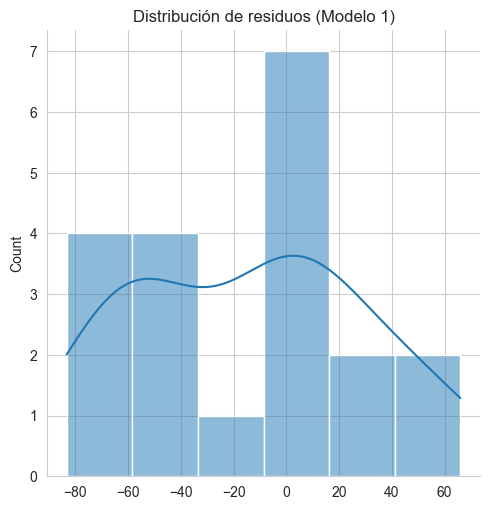

In [16]:
from sklearn import metrics

# No son exactamente iguales — calculamos los errores para cuantificar la diferencia

mae  = metrics.mean_absolute_error(diabetes_target_test, predictions)
mape = metrics.mean_absolute_percentage_error(diabetes_target_test, predictions) * 100
mse  = metrics.mean_squared_error(diabetes_target_test, predictions)
rmse = np.sqrt(mse)
r2   = diabetes_model.score(diabetes_data_test, diabetes_target_test)

print("=== Métricas del modelo (Modelo 1 — todas las variables) ===")
print(f"MAE  (Error Absoluto Medio):            {mae:.2f}")
print(f"MAPE (Error Absoluto Porcentual Medio):  {mape:.2f} %")
print(f"MSE  (Error Cuadrático Medio):           {mse:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio):  {rmse:.2f}")
print(f"R²   (Coeficiente de determinación):     {r2:.4f}")

# Histograma de residuos (debe ser aproximadamente normal para que LR sea válida)
residuals = diabetes_target_test - predictions
sns.displot(residuals, kde=True)
plt.title('Distribución de residuos (Modelo 1)')
plt.show()

#### Iterate with a new model to assess if any improvements can be made compared to the previous one. Consider reducing the number of variables or using `StandardScaler` to enhance model performance.

In [17]:
# Modelo 2: Usando StandardScaler
# Aunque los datos ya están estandarizados, demostramos el proceso completo
# como se haría con datos crudos

from sklearn.preprocessing import StandardScaler

std_scale = StandardScaler()
std_scale.fit(diabetes_data_train)

X_train_scal = std_scale.transform(diabetes_data_train)
X_test_scal  = std_scale.transform(diabetes_data_test)

diabetes_model_2 = LinearRegression()
diabetes_model_2.fit(X_train_scal, diabetes_target_train)

predictions_2 = diabetes_model_2.predict(X_test_scal)

mae2  = metrics.mean_absolute_error(diabetes_target_test, predictions_2)
mape2 = metrics.mean_absolute_percentage_error(diabetes_target_test, predictions_2) * 100
mse2  = metrics.mean_squared_error(diabetes_target_test, predictions_2)
rmse2 = np.sqrt(mse2)
r2_2  = diabetes_model_2.score(X_test_scal, diabetes_target_test)

print("=== Métricas del modelo (Modelo 2 — con StandardScaler) ===")
print(f"MAE  (Error Absoluto Medio):            {mae2:.2f}")
print(f"MAPE (Error Absoluto Porcentual Medio):  {mape2:.2f} %")
print(f"MSE  (Error Cuadrático Medio):           {mse2:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio):  {rmse2:.2f}")
print(f"R²   (Coeficiente de determinación):     {r2_2:.4f}")

print()
print("Nota: con datos ya estandarizados por sklearn, los resultados son idénticos.")
print("StandardScaler es clave cuando los datos originales tienen escalas muy diferentes.")

=== Métricas del modelo (Modelo 2 — con StandardScaler) ===
MAE  (Error Absoluto Medio):            36.61
MAPE (Error Absoluto Porcentual Medio):  39.31 %
MSE  (Error Cuadrático Medio):           2004.52
RMSE (Raíz del Error Cuadrático Medio):  44.77
R²   (Coeficiente de determinación):     0.5851

Nota: con datos ya estandarizados por sklearn, los resultados son idénticos.
StandardScaler es clave cuando los datos originales tienen escalas muy diferentes.


In [18]:
# Modelo 3: Reduciendo variables — solo las más correlacionadas con el target
# Según el análisis exploratorio, las más correlacionadas son: bmi, bp, s5, s4

feature_names = diabetes['feature_names']
selected_features = ['bmi', 'bp', 's5', 's4']
selected_idx = [feature_names.index(f) for f in selected_features]

X_train_reduced = diabetes_data_train[:, selected_idx]
X_test_reduced  = diabetes_data_test[:, selected_idx]

diabetes_model_3 = LinearRegression()
diabetes_model_3.fit(X_train_reduced, diabetes_target_train)

predictions_3 = diabetes_model_3.predict(X_test_reduced)

mae3  = metrics.mean_absolute_error(diabetes_target_test, predictions_3)
mape3 = metrics.mean_absolute_percentage_error(diabetes_target_test, predictions_3) * 100
mse3  = metrics.mean_squared_error(diabetes_target_test, predictions_3)
rmse3 = np.sqrt(mse3)
r2_3  = diabetes_model_3.score(X_test_reduced, diabetes_target_test)

print(f"=== Métricas del modelo (Modelo 3 — solo {selected_features}) ===")
print(f"MAE  (Error Absoluto Medio):            {mae3:.2f}")
print(f"MAPE (Error Absoluto Porcentual Medio):  {mape3:.2f} %")
print(f"MSE  (Error Cuadrático Medio):           {mse3:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio):  {rmse3:.2f}")
print(f"R²   (Coeficiente de determinación):     {r2_3:.4f}")

=== Métricas del modelo (Modelo 3 — solo ['bmi', 'bp', 's5', 's4']) ===
MAE  (Error Absoluto Medio):            38.68
MAPE (Error Absoluto Porcentual Medio):  42.51 %
MSE  (Error Cuadrático Medio):           2108.41
RMSE (Raíz del Error Cuadrático Medio):  45.92
R²   (Coeficiente de determinación):     0.5636


In [19]:
# Comparación final de los tres modelos
resumen = pd.DataFrame({
    'Modelo': ['Modelo 1 (todas las vars)', 'Modelo 2 (StandardScaler)', f'Modelo 3 ({selected_features})'],
    'MAE':  [mae,  mae2,  mae3],
    'MAPE': [mape, mape2, mape3],
    'RMSE': [rmse, rmse2, rmse3],
    'R²':   [r2,   r2_2,  r2_3]
})
print(resumen.to_string(index=False))

                              Modelo       MAE      MAPE      RMSE       R²
           Modelo 1 (todas las vars) 36.609619 39.308761 44.771851 0.585085
           Modelo 2 (StandardScaler) 36.609619 39.308761 44.771851 0.585085
Modelo 3 (['bmi', 'bp', 's5', 's4']) 38.681100 42.512321 45.917394 0.563582
